# Readmission cohort setup (Supabase)

Admin notebook: eligibility filtering, stratified post-day sampling, frozen intersection set, clinician assignment, and Supabase publish.

**Prerequisites**
1. Run `supabase/schema.sql` in the Supabase SQL Editor.
2. Copy `notebooks/.env.example` → `notebooks/.env` with your service role key.
3. Place cohort file at `src/data/readmit_30d.parquet`.

```bash
pip install -r notebooks/requirements.txt
```

**Artifacts** (local, not committed)
- `notebooks/artifacts/intersection_set.parquet` — shared cases for all clinicians
- `notebooks/artifacts/sampling_manifest.json` — reproducibility audit trail
- `notebooks/assignment_manifest.json` — exported assignments

**Operator flow**
1. Configure parameters + clinicians below.
2. Optional: run **Phase 1 reset** once (`RESET_DB=True`, confirm string).
3. Run **Phase 2–3** with `REBUILD_INTERSECTION=True` once to build intersection Parquet.
4. Run **Phase 4–5** to assign clinicians and publish to Supabase.
5. Re-run `polish_notes.ipynb` batch on the new assignments.
6. To add a clinician later: run **Phase 6** (incremental add). Does not touch existing assignments.

## Phase 0 — Configuration

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
from dotenv import load_dotenv
from supabase import create_client

NOTEBOOK_DIR = Path.cwd() if (Path.cwd() / "lib" / "cohort_sampling.py").exists() else Path.cwd() / "notebooks"
LIB_DIR = NOTEBOOK_DIR / "lib"
if str(LIB_DIR) not in sys.path:
    sys.path.insert(0, str(LIB_DIR))

from cohort_admin import (
    append_assignment_manifest,
    count_clinicians_with_assignments,
    ensure_user_not_assigned,
    ensure_users_and_profiles,
    fetch_assigned_row_ids,
    fetch_existing_clinician_assignments,
    print_verification,
    reset_database,
    upsert_assignments,
    upsert_cases,
    write_assignment_manifest,
)
from cohort_sampling import (
    SamplingConfig,
    assert_only_intersection_shared,
    assign_all_clinicians,
    assign_single_clinician,
    build_intersection_set,
    config_for_clinician,
    filter_eligible_cohort,
    load_intersection_artifact,
    reserved_unique_row_ids,
    save_intersection_artifact,
    union_assigned_rows,
)

load_dotenv(NOTEBOOK_DIR / ".env")
load_dotenv(Path(".env"))

SUPABASE_URL = os.environ["SUPABASE_URL"]
SUPABASE_SERVICE_ROLE_KEY = os.environ["SUPABASE_SERVICE_ROLE_KEY"]

REPO_ROOT = (
    NOTEBOOK_DIR.parent
    if (NOTEBOOK_DIR.parent / "supabase" / "schema.sql").exists()
    else NOTEBOOK_DIR
)
PARQUET_PATH = Path(os.getenv("PARQUET_PATH", REPO_ROOT / "src" / "data" / "readmit_30d.parquet"))
ARTIFACTS_DIR = NOTEBOOK_DIR / "artifacts"
INTERSECTION_PARQUET = Path(os.getenv("INTERSECTION_PARQUET", ARTIFACTS_DIR / "intersection_set.parquet"))
SAMPLING_MANIFEST = Path(os.getenv("SAMPLING_MANIFEST", ARTIFACTS_DIR / "sampling_manifest.json"))
MANIFEST_PATH = REPO_ROOT / "notebooks" / "assignment_manifest.json"

CASES_PER_CLINICIAN = int(os.getenv("CASES_PER_CLINICIAN", "30"))
INTERSECTION_SIZE = int(os.getenv("INTERSECTION_SIZE", "10"))
RANDOM_SEED = int(os.getenv("RANDOM_SEED", "42"))
NOTE_LENGTH_MIN_PERCENTILE = float(os.getenv("NOTE_LENGTH_MIN_PERCENTILE", "30"))
NOTE_LENGTH_MAX_PERCENTILE = float(os.getenv("NOTE_LENGTH_MAX_PERCENTILE", "90"))
MIN_COMBINED_NOTE_CHARS = int(os.getenv("MIN_COMBINED_NOTE_CHARS", "400"))
POSTDAY_BIN_WIDTH = int(os.getenv("POSTDAY_BIN_WIDTH", "5"))
REBUILD_INTERSECTION = os.getenv("REBUILD_INTERSECTION", "false").lower() in ("1", "true", "yes")
RESET_DB = os.getenv("RESET_DB", "false").lower() in ("1", "true", "yes")
CONFIRM_RESET = os.getenv("CONFIRM_RESET", "")

CLINICIANS = [
    {
        "email": "krumholz@yale.edu",
        "password": "welcome",
        "display_name": "Prof. Harlan Krumholz",
    },
    {
        "email": "karthik@yale.edu",
        "password": "welcome",
        "display_name": "Prof. Karthik Murugiah",
    },
]

CONFIG = SamplingConfig(
    cases_per_clinician=CASES_PER_CLINICIAN,
    intersection_size=INTERSECTION_SIZE,
    random_seed=RANDOM_SEED,
    note_length_min_percentile=NOTE_LENGTH_MIN_PERCENTILE,
    note_length_max_percentile=NOTE_LENGTH_MAX_PERCENTILE,
    min_combined_note_chars=MIN_COMBINED_NOTE_CHARS,
    postday_bin_width=POSTDAY_BIN_WIDTH,
)

sb = create_client(SUPABASE_URL, SUPABASE_SERVICE_ROLE_KEY)
print("Supabase client ready")
print("Parquet:", PARQUET_PATH)
print("Config:", CONFIG)
print("Clinicians:", [c["email"] for c in CLINICIANS])

Supabase client ready
Parquet: c:\Users\Lough\Desktop\Research\[Yale] Postdoctoral Research\Readmission\src\data\readmit_30d.parquet
Config: SamplingConfig(cases_per_clinician=30, intersection_size=10, random_seed=42, note_length_min_percentile=30.0, note_length_max_percentile=90.0, min_combined_note_chars=400, postday_bin_width=5, readmission_window_days=30)
Clinicians: ['krumholz@yale.edu', 'karthik@yale.edu']


## Phase 1 — Full database reset (optional)

Set `RESET_DB = True` and `CONFIRM_RESET = "DELETE ALL"` in the cell below before running.

Deletes annotations → assignments → cases → profiles → Auth users.

In [2]:
RESET_DB = True  # set True to wipe Supabase cohort data
CONFIRM_RESET = "DELETE ALL"  # must be exactly: DELETE ALL

if RESET_DB:
    if CONFIRM_RESET != "DELETE ALL":
        raise RuntimeError('Set CONFIRM_RESET = "DELETE ALL" to proceed with reset')
    summary = reset_database(sb)
    print(json.dumps(summary, indent=2))
else:
    print("Skipping reset (RESET_DB=False)")

{
  "before": {
    "annotations": 0,
    "assignments": 0,
    "cases": 0,
    "profiles": 0,
    "auth_users": 0
  },
  "after": {
    "annotations": 0,
    "assignments": 0,
    "cases": 0,
    "profiles": 0,
    "auth_users": 0
  }
}


## Phase 2 — Load cohort and eligibility filters

In [3]:
if not PARQUET_PATH.is_file():
    raise FileNotFoundError(f"Cohort file not found: {PARQUET_PATH}")

raw_df = pq.read_table(PARQUET_PATH).to_pandas()
raw_df = raw_df[raw_df["row_id"].notna()].copy()
raw_df["row_id"] = raw_df["row_id"].astype(str)

eligible_df, exclusion_report = filter_eligible_cohort(raw_df, CONFIG)
CONFIG.validate(len(CLINICIANS), len(eligible_df))

print("Total rows:", exclusion_report.total_rows)
print("Eligible rows:", exclusion_report.eligible_rows)
print(json.dumps(exclusion_report.to_dict(), indent=2))
eligible_df[["row_id", "postday", "postday_bin", "combined_note_len"]].head()

Total rows: 908
Eligible rows: 529
{
  "total_rows": 908,
  "missing_row_id": 0,
  "missing_days_to_readmit": 0,
  "missing_index_note": 6,
  "missing_readmit_note": 19,
  "empty_index_note": 6,
  "empty_readmit_note": 19,
  "out_of_window_postday": 0,
  "below_min_note_length": 265,
  "above_max_note_length": 89,
  "eligible_rows": 529,
  "min_combined_length_threshold": 20399.8,
  "max_combined_length_threshold": 38775.0
}


,row_id,postday,postday_bin,combined_note_len
0,0,1,0,21839
3,3,7,1,21775
4,4,4,0,24585
6,6,27,5,36733
7,7,14,2,23197


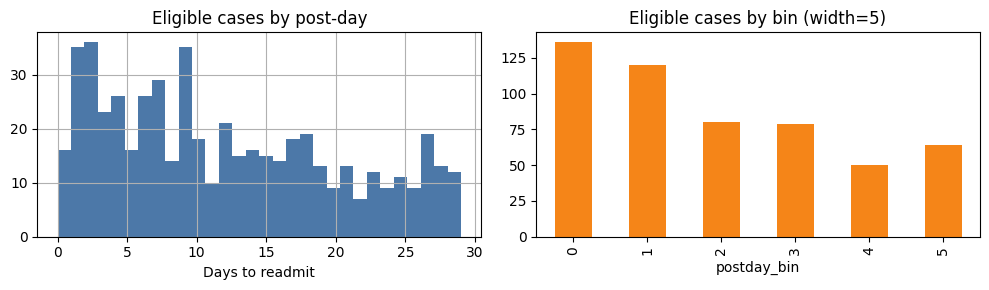

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
eligible_df["postday"].hist(bins=30, ax=axes[0], color="#4C78A8")
axes[0].set_title("Eligible cases by post-day")
axes[0].set_xlabel("Days to readmit")
eligible_df.groupby("postday_bin").size().sort_index().plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title(f"Eligible cases by bin (width={CONFIG.postday_bin_width})")
plt.tight_layout()
plt.show()

## Phase 3 — Intersection set (shared across all clinicians)

Run with `REBUILD_INTERSECTION=True` once to create the Parquet artifact.
Later runs should load the saved intersection set.

In [5]:
REBUILD_INTERSECTION = True  # set False after first successful build

if REBUILD_INTERSECTION:
    intersection_df, intersection_report = build_intersection_set(eligible_df, CONFIG)
    save_intersection_artifact(
        intersection_df,
        CONFIG,
        exclusion_report,
        intersection_report,
        parquet_path=INTERSECTION_PARQUET,
        manifest_path=SAMPLING_MANIFEST,
    )
    intersection_ids = intersection_df["row_id"].tolist()
    print(f"Built intersection set: {len(intersection_ids)} cases")
    print("Saved:", INTERSECTION_PARQUET)
    print("Saved:", SAMPLING_MANIFEST)
else:
    intersection_ids, intersection_df = load_intersection_artifact(INTERSECTION_PARQUET)
    from cohort_sampling import validate_intersection_in_pool

    validate_intersection_in_pool(intersection_ids, eligible_df)
    print(f"Loaded intersection set: {len(intersection_ids)} cases from {INTERSECTION_PARQUET}")

print("Intersection row_ids:", intersection_ids)

Built intersection set: 10 cases
Saved: c:\Users\Lough\Desktop\Research\[Yale] Postdoctoral Research\Readmission\notebooks\artifacts\intersection_set.parquet
Saved: c:\Users\Lough\Desktop\Research\[Yale] Postdoctoral Research\Readmission\notebooks\artifacts\sampling_manifest.json
Intersection row_ids: ['69', '71', '120', '463', '469', '519', '634', '715', '721', '727']


## Phase 4 — Assign cases to clinicians

In [6]:
splits, assignment_audit = assign_all_clinicians(
    eligible_df,
    CLINICIANS,
    intersection_ids,
    CONFIG,
)

selected_df = union_assigned_rows(eligible_df, splits)

for clinician, row_ids in splits:
    print(f"{clinician['email']}: {len(row_ids)} cases ({CONFIG.intersection_size} shared)")

if SAMPLING_MANIFEST.is_file():
    manifest = json.loads(SAMPLING_MANIFEST.read_text(encoding="utf-8"))
else:
    manifest = {"config": CONFIG.__dict__}
manifest["assignment_audit"] = assignment_audit
SAMPLING_MANIFEST.write_text(json.dumps(manifest, indent=2), encoding="utf-8")
print(f"Unique cases selected for upsert: {len(selected_df)}")

krumholz@yale.edu: 30 cases (10 shared)
karthik@yale.edu: 30 cases (10 shared)
Unique cases selected for upsert: 50


## Phase 5 — Publish to Supabase

In [7]:
# Merge eligible columns back onto full raw rows for any metadata fields
publish_df = raw_df[raw_df["row_id"].isin(selected_df["row_id"])].copy()
upserted = upsert_cases(sb, publish_df)
print(f"Upserted {upserted} cases")

Upserted 50 cases


In [8]:
user_ids = ensure_users_and_profiles(sb, CLINICIANS)
print("Profiles upserted for", list(user_ids.keys()))

Profiles upserted for ['krumholz@yale.edu', 'karthik@yale.edu']


In [9]:
assignment_count, manifest = upsert_assignments(sb, splits, user_ids)
print(f"Created {assignment_count} assignments")

Created 60 assignments


## Verification + manifest export

In [10]:
print_verification(sb, CLINICIANS, user_ids)
write_assignment_manifest(manifest, MANIFEST_PATH)
print("Wrote manifest:", MANIFEST_PATH)

Cases in DB: 50
Assignments in DB: 60
  krumholz@yale.edu: 30 assignments
  karthik@yale.edu: 30 assignments
Wrote manifest: c:\Users\Lough\Desktop\Research\[Yale] Postdoctoral Research\Readmission\notebooks\assignment_manifest.json


## Phase 6 — Add a clinician (incremental)

Use this after Phases 2–5 have already run and existing clinicians may have started annotating.

- Loads the **frozen intersection** from `intersection_set.parquet` (do not rebuild).
- Samples **unique** cases only from the remaining pool (excludes every non-intersection case already assigned in Supabase).
- Creates the new Auth user + profile and **only** that clinician's assignments — existing assignments are not touched.
- Overlap with each existing clinician is validated to be **exactly** the intersection set.

**Prerequisites:** Phase 2 (`eligible_df`) must be in memory, or re-run Phase 2 first.

In [ ]:
# --- configure the new clinician here ---
NEW_CLINICIAN = {
    "email": "adith.arun@yale.edu",
    "password": "welcome",
    "display_name": "Dr. Adith Arun",
    # Optional overrides (defaults to CASES_PER_CLINICIAN / INTERSECTION_SIZE above):
    # "cases_per_clinician": 30,
    # "intersection_size": 10,
}

if "eligible_df" not in globals():
    raise RuntimeError("Run Phase 2 first to create eligible_df")

new_config = config_for_clinician(CONFIG, NEW_CLINICIAN)
if new_config.intersection_size != INTERSECTION_SIZE:
    raise ValueError(
        f"NEW_CLINICIAN intersection_size ({new_config.intersection_size}) must match "
        f"frozen INTERSECTION_SIZE ({INTERSECTION_SIZE})"
    )

intersection_ids, _ = load_intersection_artifact(INTERSECTION_PARQUET)
if len(intersection_ids) != new_config.intersection_size:
    raise ValueError(
        f"Intersection artifact has {len(intersection_ids)} cases but config expects "
        f"{new_config.intersection_size}"
    )

ensure_user_not_assigned(sb, NEW_CLINICIAN["email"])

all_assigned = fetch_assigned_row_ids(sb)
if not all_assigned:
    raise RuntimeError("No existing assignments in Supabase — run Phases 4–5 first")

reserved_unique = reserved_unique_row_ids(all_assigned, intersection_ids)
clinician_index = count_clinicians_with_assignments(sb)

new_row_ids, add_audit = assign_single_clinician(
    eligible_df,
    NEW_CLINICIAN,
    intersection_ids,
    new_config,
    reserved_unique_row_ids=reserved_unique,
    clinician_index=clinician_index,
)

for email, existing_row_ids in fetch_existing_clinician_assignments(sb):
    assert_only_intersection_shared(
        new_row_ids,
        existing_row_ids,
        intersection_ids,
        existing_label=email,
    )

new_unique_ids = new_row_ids[new_config.intersection_size :]
overlap_with_reserved = set(new_unique_ids) & reserved_unique
if overlap_with_reserved:
    raise RuntimeError(f"Unique overlap with existing assignments: {sorted(overlap_with_reserved)[:5]}")

print(f"Assigning {NEW_CLINICIAN['email']}:")
print(f"  {new_config.intersection_size} shared intersection cases")
print(f"  {len(new_unique_ids)} unique cases")
print(f"  Excluded {len(reserved_unique)} unique cases already assigned to others")

# Upsert only the new clinician's cases (intersection rows likely already exist)
new_case_ids = list(dict.fromkeys(new_row_ids))
publish_df = raw_df[raw_df["row_id"].isin(new_case_ids)].copy()
upserted = upsert_cases(sb, publish_df)
print(f"Upserted {upserted} case rows (includes intersection overlap)")

user_ids = ensure_users_and_profiles(sb, [NEW_CLINICIAN])
assignment_count, new_manifest = upsert_assignments(
    sb,
    [(NEW_CLINICIAN, new_row_ids)],
    user_ids,
)
print(f"Created {assignment_count} assignments for {NEW_CLINICIAN['email']}")

append_assignment_manifest(new_manifest, MANIFEST_PATH)
print("Appended to manifest:", MANIFEST_PATH)

if SAMPLING_MANIFEST.is_file():
    manifest = json.loads(SAMPLING_MANIFEST.read_text(encoding="utf-8"))
else:
    manifest = {"config": CONFIG.__dict__}
manifest.setdefault("incremental_adds", []).append(add_audit)
SAMPLING_MANIFEST.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print_verification(sb, [NEW_CLINICIAN], user_ids)
print("Next: run polish_notes.ipynb batch for the new assignments only.")